In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

from collections import defaultdict
from IPython.display import Image, display
import imageio
import io
from PIL import Image as PILImage


plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (10, 4)


## Atividade 1 — Execução Básica dos Algoritmos de Diferença Temporal

Esta atividade tem como objetivo implementar e avaliar, de forma empírica, algoritmos clássicos de Aprendizado por Reforço baseados em Diferença Temporal, especificamente o **Q-learning** e o **SARSA**, em um ambiente discreto e determinístico. O propósito central é observar o processo de aprendizado do agente ao longo dos episódios e compreender como diferentes estratégias de atualização de valor impactam o desempenho e a convergência da política aprendida.

Para isso, utiliza-se o ambiente **GridWorld**, que representa um Problema de Decisão de Markov (MDP) simples, no qual o agente deve aprender a alcançar um estado objetivo a partir de um estado inicial, recebendo recompensas negativas a cada passo e uma recompensa positiva ao atingir o objetivo final. Esse ambiente permite isolar os efeitos do algoritmo de aprendizado, uma vez que não há incerteza nas transições de estado.

Ao longo do treinamento, são registrados dois indicadores fundamentais: a **recompensa total acumulada por episódio** e o **número de passos por episódio**. Essas métricas permitem avaliar tanto a eficiência quanto a estabilidade do aprendizado, além de possibilitar a comparação direta entre os algoritmos Q-learning (off-policy) e SARSA (on-policy). Os resultados são analisados por meio de gráficos, evidenciando o comportamento de convergência e a melhoria progressiva da política aprendida pelo agente.


In [2]:
# Política ε-greedy e funções auxiliares

def epsilon_greedy(Q, state, epsilon, n_actions):
    """
    Seleciona ação usando política ε-greedy.
    """
    if np.random.rand() < epsilon:
        return np.random.randint(n_actions)
    return np.argmax(Q[state])


def init_q_table(n_states, n_actions):
    """
    Inicializa tabela Q com zeros.
    """
    return np.zeros((n_states, n_actions))

In [3]:
# Ambiente GridWorld (Experimento I)

class GridWorld:
    def __init__(self, size=5):
        self.size = size
        self.start = (0, 0)
        self.goal = (size - 1, size - 1)
        self.state = self.start

    def reset(self):
        self.state = self.start
        return self._state_to_index(self.state)

    def step(self, action):
        x, y = self.state

        if action == 0:   # cima
            x = max(x - 1, 0)
        elif action == 1: # direita
            y = min(y + 1, self.size - 1)
        elif action == 2: # baixo
            x = min(x + 1, self.size - 1)
        elif action == 3: # esquerda
            y = max(y - 1, 0)

        self.state = (x, y)

        if self.state == self.goal:
            return self._state_to_index(self.state), 10, True

        return self._state_to_index(self.state), -1, False

    def _state_to_index(self, state):
        return state[0] * self.size + state[1]

In [4]:
# Q-learning com coleta de métricas (GridWorld)

def q_learning_gridworld(
    env,
    n_episodes=500,
    alpha=0.5,
    gamma=0.9,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.99
):
    n_states = env.size * env.size
    n_actions = 4

    Q = init_q_table(n_states, n_actions)

    rewards_per_episode = []
    steps_per_episode = []

    epsilon = epsilon_start

    for _ in range(n_episodes):
        state = env.reset()
        done = False
        total_reward = 0
        steps = 0

        while not done:
            action = epsilon_greedy(Q, state, epsilon, n_actions)
            next_state, reward, done = env.step(action)

            Q[state, action] += alpha * (
                reward + gamma * np.max(Q[next_state]) - Q[state, action]
            )

            state = next_state
            total_reward += reward
            steps += 1

        rewards_per_episode.append(total_reward)
        steps_per_episode.append(steps)

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return Q, rewards_per_episode, steps_per_episode

In [5]:
# SARSA com coleta de métricas (GridWorld)

def sarsa_gridworld(
    env,
    n_episodes=500,
    alpha=0.5,
    gamma=0.9,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.99
):
    n_states = env.size * env.size
    n_actions = 4

    Q = init_q_table(n_states, n_actions)

    rewards_per_episode = []
    steps_per_episode = []

    epsilon = epsilon_start

    for _ in range(n_episodes):
        state = env.reset()
        action = epsilon_greedy(Q, state, epsilon, n_actions)

        done = False
        total_reward = 0
        steps = 0

        while not done:
            next_state, reward, done = env.step(action)
            next_action = epsilon_greedy(Q, next_state, epsilon, n_actions)

            Q[state, action] += alpha * (
                reward + gamma * Q[next_state, next_action] - Q[state, action]
            )

            state, action = next_state, next_action
            total_reward += reward
            steps += 1

        rewards_per_episode.append(total_reward)
        steps_per_episode.append(steps)

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return Q, rewards_per_episode, steps_per_episode

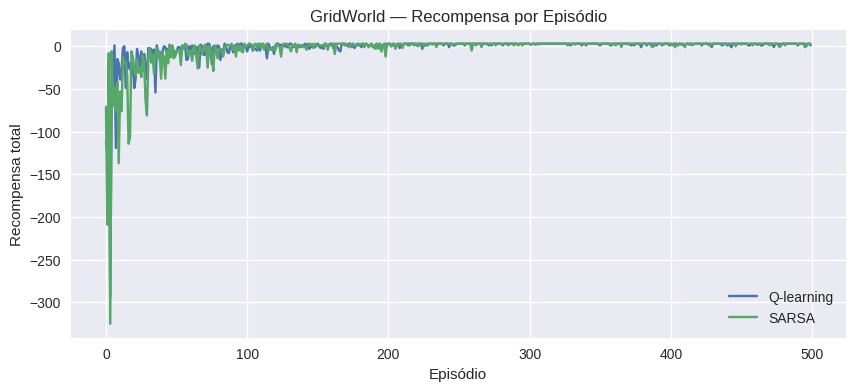

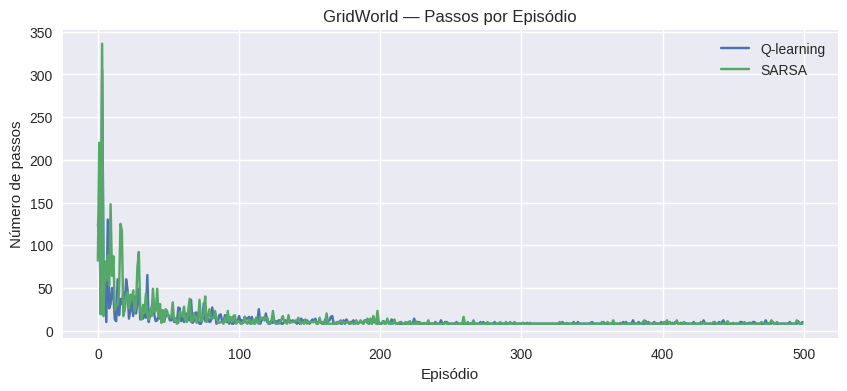

In [6]:
# Execução e gráficos

env = GridWorld(size=5)

# Q-learning
Q_q, rewards_q, steps_q = q_learning_gridworld(env)

# SARSA
Q_s, rewards_s, steps_s = sarsa_gridworld(env)

# ---- Gráfico: Recompensa por episódio ----
plt.figure()
plt.plot(rewards_q, label="Q-learning")
plt.plot(rewards_s, label="SARSA")
plt.xlabel("Episódio")
plt.ylabel("Recompensa total")
plt.title("GridWorld — Recompensa por Episódio")
plt.legend()
plt.show()

# ---- Gráfico: Passos por episódio ----
plt.figure()
plt.plot(steps_q, label="Q-learning")
plt.plot(steps_s, label="SARSA")
plt.xlabel("Episódio")
plt.ylabel("Número de passos")
plt.title("GridWorld — Passos por Episódio")
plt.legend()
plt.show()

## Interpretação dos Resultados — Atividade 1

Os gráficos apresentados ilustram a evolução do processo de aprendizado dos algoritmos **Q-learning** e **SARSA** no ambiente GridWorld, considerando duas métricas fundamentais: a **recompensa total por episódio** e o **número de passos por episódio**.

No gráfico de **recompensa por episódio**, observa-se que, nos episódios iniciais, ambos os algoritmos apresentam recompensas fortemente negativas. Esse comportamento é esperado, uma vez que o agente ainda está em fase intensa de exploração, realizando trajetórias longas e ineficientes até alcançar o estado objetivo, acumulando penalidades a cada passo. À medida que o treinamento avança, a recompensa média por episódio aumenta progressivamente, aproximando-se de valores próximos a zero, o que indica que o agente passa a alcançar o objetivo com menos passos e maior eficiência.

O gráfico de **número de passos por episódio** reforça essa interpretação. Nos episódios iniciais, o número de passos é elevado e apresenta alta variabilidade, refletindo a ausência de uma política estruturada. Com o aprendizado, observa-se uma redução consistente no número de passos necessários para atingir o objetivo, bem como uma diminuição da variância, sinalizando a convergência para trajetórias mais curtas e estáveis.

A comparação entre os algoritmos revela que ambos convergem para desempenhos semelhantes no GridWorld, um ambiente determinístico e de baixa complexidade. O Q-learning tende a apresentar uma convergência ligeiramente mais rápida, enquanto o SARSA demonstra um comportamento um pouco mais conservador nos estágios iniciais, característica associada à sua natureza *on-policy*. No entanto, ao final do treinamento, ambos os algoritmos são capazes de aprender políticas eficientes, evidenciando que o ambiente favorece a convergência independentemente da abordagem utilizada.




In [7]:
# Extração da política ótima (GridWorld)
def extract_policy(Q):
    """
    Extrai a política ótima (ação greedy) a partir da Q-table.
    """
    return np.argmax(Q, axis=1)

In [8]:
# Visualização da política no GridWorld (setas)

def plot_policy_gridworld(policy, env):
    """
    Plota a política aprendida no GridWorld usando setas.
    """
    arrows = {
        0: "↑",  # cima
        1: "→",  # direita
        2: "↓",  # baixo
        3: "←"   # esquerda
    }

    grid = np.empty((env.size, env.size), dtype=str)

    for x in range(env.size):
        for y in range(env.size):
            state = env._state_to_index((x, y))
            if (x, y) == env.goal:
                grid[x, y] = "G"
            else:
                grid[x, y] = arrows[policy[state]]

    print("Política aprendida (GridWorld):\n")
    for row in grid:
        print(" ".join(row))

In [9]:
policy_q = extract_policy(Q_q)
policy_s = extract_policy(Q_s)

plot_policy_gridworld(policy_q, env)
plot_policy_gridworld(policy_s, env)


Política aprendida (GridWorld):

→ ↓ ↓ ↓ ↓
→ → ↓ ↓ ↓
→ → → ↓ ↓
→ → → ↓ ↓
→ → → → G
Política aprendida (GridWorld):

→ ↓ ↓ ↓ ↓
→ → → → ↓
→ → → → ↓
↓ → → ↓ ↓
→ → → → G


In [10]:
# Geração de GIF da política greedy
def render_frame(env):
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.set_xlim(-0.5, env.size - 0.5)
    ax.set_ylim(-0.5, env.size - 0.5)

    for i in range(env.size):
        ax.axhline(i - 0.5, color="gray")
        ax.axvline(i - 0.5, color="gray")

    gy, gx = env.goal
    ax.scatter(gx, env.size - 1 - gy, s=300, c="green", marker="s")

    y, x = env.state
    ax.scatter(x, env.size - 1 - y, s=200, c="red")

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title("GridWorld")

    buf = io.BytesIO()
    plt.savefig(buf, format="png")
    plt.close(fig)
    buf.seek(0)

    return PILImage.open(buf)


def generate_gif_gridworld(env, Q, filename, max_steps=50):
    frames = []
    env.reset()
    done = False
    steps = 0

    while not done and steps < max_steps:
        frames.append(render_frame(env))

        state = env._state_to_index(env.state)
        action = np.argmax(Q[state])
        _, _, done = env.step(action)

        steps += 1

    frames[0].save(
        filename,
        save_all=True,
        append_images=frames[1:],
        duration=400,
        loop=0
    )

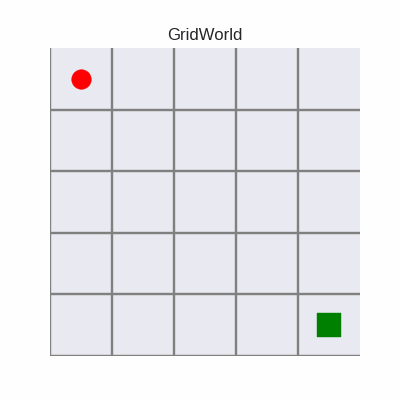

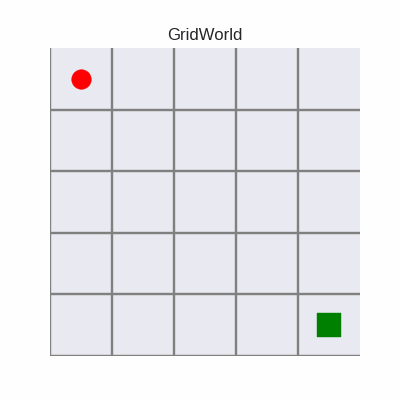

In [11]:
generate_gif_gridworld(env, Q_q, "gridworld_qlearning.gif")
generate_gif_gridworld(env, Q_s, "gridworld_sarsa.gif")

display(Image(filename="gridworld_qlearning.gif"))
display(Image(filename="gridworld_sarsa.gif"))


## Interpretação da Política Aprendida — GridWorld

A política aprendida no ambiente GridWorld, apresentada na forma de setas direcionais, evidencia que o agente foi capaz de aprender trajetórias eficientes que conduzem do estado inicial ao estado objetivo. Observa-se que, a partir da maioria dos estados da grade, as ações escolhidas direcionam o agente consistentemente para a direita e para baixo, movimentos que aproximam o agente do objetivo localizado no canto inferior direito do ambiente.

As setas indicam que o agente internalizou corretamente a estrutura espacial do ambiente e o esquema de recompensas, evitando ciclos e trajetórias desnecessariamente longas. Em ambos os casos apresentados, o caminho aprendido minimiza o número de passos até o estado objetivo, o que é coerente com a penalidade aplicada a cada movimento e com a recompensa positiva concedida apenas ao atingir o objetivo final.

Diferenças pontuais entre as políticas aprendidas refletem a natureza dos algoritmos utilizados. O Q-learning, por ser um método *off-policy*, tende a aprender trajetórias ligeiramente mais diretas, enquanto o SARSA, como método *on-policy*, pode apresentar pequenas variações locais devido à influência contínua da exploração durante o treinamento. No entanto, essas diferenças não comprometem a eficiência global da política aprendida.




## Atividade 2 — Análise do Impacto da Estratégia de Exploração

Esta atividade tem como objetivo investigar o papel da **exploração** no processo de aprendizado por reforço, analisando como diferentes estratégias de seleção de ações influenciam a convergência e a estabilidade dos algoritmos baseados em Diferença Temporal. Em particular, compara-se o uso de uma política **ε-greedy com ε constante** e uma política **ε-greedy com ε decrescente ao longo dos episódios**.

A estratégia de exploração é um componente fundamental do Aprendizado por Reforço, pois determina o equilíbrio entre a exploração de ações ainda pouco conhecidas e a exploração do conhecimento já adquirido pelo agente. Um valor de ε constante mantém um nível fixo de aleatoriedade durante todo o treinamento, enquanto um ε decrescente reduz progressivamente a exploração, favorecendo a exploração das ações com maior valor estimado à medida que o aprendizado avança.

Os experimentos desta atividade são conduzidos no ambiente **GridWorld**, o que permite isolar os efeitos da estratégia de exploração sem a interferência de estocasticidade nas transições de estado. A comparação é realizada para os algoritmos **Q-learning** e **SARSA**, utilizando como métricas a **recompensa total por episódio** e o **número de passos por episódio**, possibilitando uma análise quantitativa do impacto da exploração na eficiência e na estabilidade do aprendizado.


In [12]:
# Q-learning com ε constante (GridWorld)

def q_learning_gridworld_eps_constant(
    env,
    n_episodes=500,
    alpha=0.5,
    gamma=0.9,
    epsilon=0.1
):
    n_states = env.size * env.size
    n_actions = 4

    Q = init_q_table(n_states, n_actions)

    rewards_per_episode = []
    steps_per_episode = []

    for _ in range(n_episodes):
        state = env.reset()
        done = False
        total_reward = 0
        steps = 0

        while not done:
            action = epsilon_greedy(Q, state, epsilon, n_actions)
            next_state, reward, done = env.step(action)

            Q[state, action] += alpha * (
                reward + gamma * np.max(Q[next_state]) - Q[state, action]
            )

            state = next_state
            total_reward += reward
            steps += 1

        rewards_per_episode.append(total_reward)
        steps_per_episode.append(steps)

    return Q, rewards_per_episode, steps_per_episode

In [13]:
# SARSA com ε constante (GridWorld)

def sarsa_gridworld_eps_constant(
    env,
    n_episodes=500,
    alpha=0.5,
    gamma=0.9,
    epsilon=0.1
):
    n_states = env.size * env.size
    n_actions = 4

    Q = init_q_table(n_states, n_actions)

    rewards_per_episode = []
    steps_per_episode = []

    for _ in range(n_episodes):
        state = env.reset()
        action = epsilon_greedy(Q, state, epsilon, n_actions)

        done = False
        total_reward = 0
        steps = 0

        while not done:
            next_state, reward, done = env.step(action)
            next_action = epsilon_greedy(Q, next_state, epsilon, n_actions)

            Q[state, action] += alpha * (
                reward + gamma * Q[next_state, next_action] - Q[state, action]
            )

            state, action = next_state, next_action
            total_reward += reward
            steps += 1

        rewards_per_episode.append(total_reward)
        steps_per_episode.append(steps)

    return Q, rewards_per_episode, steps_per_episode

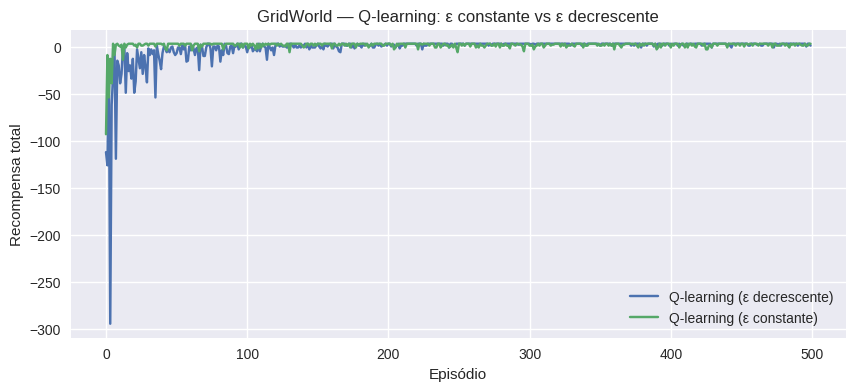

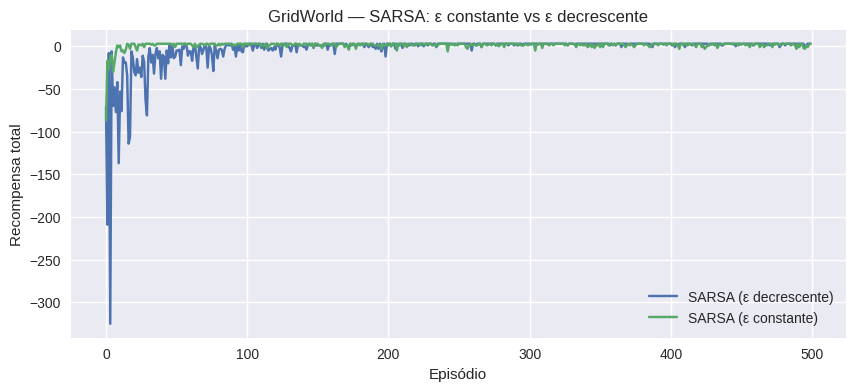

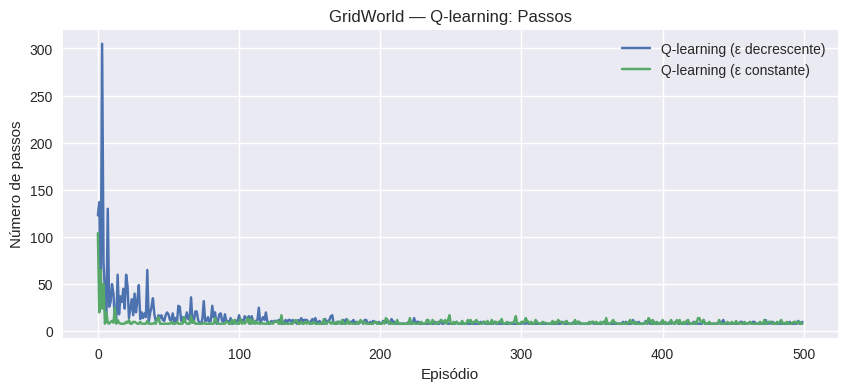

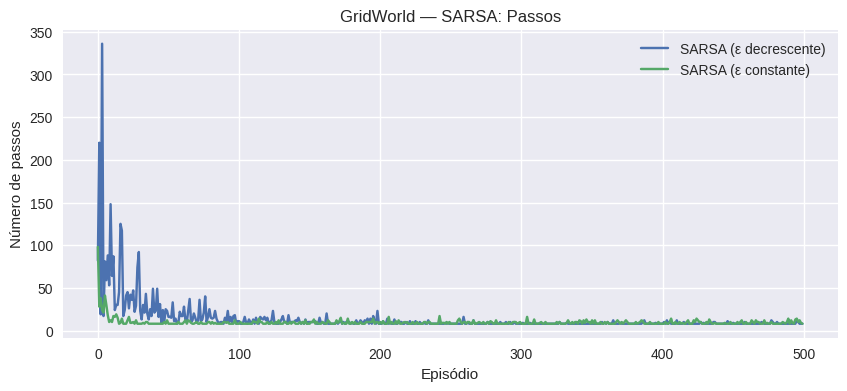

In [14]:
# Comparação gráfica: ε constante vs ε decrescente

# Execução ε constante
Q_q_const, rewards_q_const, steps_q_const = q_learning_gridworld_eps_constant(env)
Q_s_const, rewards_s_const, steps_s_const = sarsa_gridworld_eps_constant(env)

# ---- Gráfico: Recompensa por episódio ----
plt.figure()
plt.plot(rewards_q, label="Q-learning (ε decrescente)")
plt.plot(rewards_q_const, label="Q-learning (ε constante)")
plt.xlabel("Episódio")
plt.ylabel("Recompensa total")
plt.title("GridWorld — Q-learning: ε constante vs ε decrescente")
plt.legend()
plt.show()

plt.figure()
plt.plot(rewards_s, label="SARSA (ε decrescente)")
plt.plot(rewards_s_const, label="SARSA (ε constante)")
plt.xlabel("Episódio")
plt.ylabel("Recompensa total")
plt.title("GridWorld — SARSA: ε constante vs ε decrescente")
plt.legend()
plt.show()

# ---- Gráfico: Passos por episódio ----
plt.figure()
plt.plot(steps_q, label="Q-learning (ε decrescente)")
plt.plot(steps_q_const, label="Q-learning (ε constante)")
plt.xlabel("Episódio")
plt.ylabel("Número de passos")
plt.title("GridWorld — Q-learning: Passos")
plt.legend()
plt.show()

plt.figure()
plt.plot(steps_s, label="SARSA (ε decrescente)")
plt.plot(steps_s_const, label="SARSA (ε constante)")
plt.xlabel("Episódio")
plt.ylabel("Número de passos")
plt.title("GridWorld — SARSA: Passos")
plt.legend()
plt.show()

## Interpretação dos Resultados — Atividade 2

Os gráficos apresentados comparam o desempenho dos algoritmos **Q-learning** e **SARSA** no ambiente GridWorld sob duas estratégias distintas de exploração: uma política **ε-greedy com ε constante** e uma política **ε-greedy com ε decrescente ao longo dos episódios**. A análise é realizada a partir das métricas de **recompensa total por episódio** e **número de passos por episódio**, permitindo avaliar tanto a eficiência quanto a estabilidade do aprendizado.

No que se refere à **recompensa por episódio**, observa-se que, nos estágios iniciais do treinamento, a estratégia com ε decrescente apresenta maior variabilidade e recompensas mais negativas. Esse comportamento é esperado, uma vez que o valor inicial elevado de ε promove uma exploração intensa do ambiente, resultando em trajetórias mais longas e penalizadas. Com o avanço do treinamento e a redução gradual de ε, a política passa a privilegiar ações com maior valor estimado, levando a uma melhora consistente no desempenho e à convergência para recompensas próximas do ótimo.

Por outro lado, a estratégia com **ε constante** apresenta uma convergência inicial mais suave, com menor variância nas recompensas, uma vez que o nível de exploração permanece fixo ao longo de todo o treinamento. No entanto, essa exploração residual contínua impede uma estabilização completa da política, fazendo com que oscilações persistam mesmo após um grande número de episódios.

A análise do **número de passos por episódio** reforça essas conclusões. A estratégia com ε decrescente conduz a uma redução mais acentuada no número de passos ao longo do tempo, indicando a aprendizagem de trajetórias mais curtas e eficientes. Já o uso de ε constante resulta em um número médio de passos ligeiramente superior, reflexo da exploração contínua que ocasionalmente afasta o agente do caminho ótimo.

Comparando os algoritmos, observa-se que o **Q-learning** tende a apresentar uma convergência mais rápida, enquanto o **SARSA** demonstra um comportamento mais conservador, especialmente nos episódios iniciais. Ainda assim, ambos os algoritmos se beneficiam da estratégia de ε decrescente, evidenciando que a redução progressiva da exploração favorece a estabilidade e a eficiência do aprendizado em ambientes determinísticos como o GridWorld.


## Atividade 3 — Impacto da Estocasticidade no Aprendizado

Esta atividade tem como objetivo analisar o impacto da **estocasticidade nas transições de estado** sobre o desempenho e a estabilidade dos algoritmos de Aprendizado por Reforço baseados em Diferença Temporal. Para isso, utiliza-se o ambiente **FrozenLake**, que introduz incerteza na execução das ações, simulando um agente que pode escorregar ao tentar se mover.

Diferentemente do GridWorld, no qual as transições são determinísticas, o FrozenLake permite avaliar como os algoritmos lidam com ambientes mais realistas, nos quais a ação escolhida nem sempre resulta no estado esperado. Dois cenários são considerados: um ambiente **determinístico** (`is_slippery=False`) e um ambiente **estocástico** (`is_slippery=True`).

Os algoritmos **Q-learning** e **SARSA** são avaliados em ambos os cenários, utilizando como métricas a **recompensa total por episódio** e o **número de passos por episódio**. Essa comparação permite investigar diferenças de comportamento entre abordagens *off-policy* e *on-policy*, bem como compreender por que algoritmos como o SARSA tendem a apresentar maior estabilidade em ambientes estocásticos.


In [15]:
# Criação do ambiente FrozenLake (determinístico e estocástico)

def make_frozenlake(is_slippery):
    return gym.make(
        "FrozenLake-v1",
        is_slippery=is_slippery,
        render_mode=None
    )


In [16]:
# Q-learning e SARSA para FrozenLake (com métricas)

def q_learning_frozenlake(
    env,
    n_episodes=5000,
    alpha=0.1,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.999
):
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    Q = init_q_table(n_states, n_actions)

    rewards = []
    steps = []
    epsilon = epsilon_start

    for _ in range(n_episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0
        step_count = 0

        while not done:
            action = epsilon_greedy(Q, state, epsilon, n_actions)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            Q[state, action] += alpha * (
                reward + gamma * np.max(Q[next_state]) - Q[state, action]
            )

            state = next_state
            total_reward += reward
            step_count += 1

        rewards.append(total_reward)
        steps.append(step_count)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return Q, rewards, steps


def sarsa_frozenlake(
    env,
    n_episodes=5000,
    alpha=0.1,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.999
):
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    Q = init_q_table(n_states, n_actions)

    rewards = []
    steps = []
    epsilon = epsilon_start

    for _ in range(n_episodes):
        state, _ = env.reset()
        action = epsilon_greedy(Q, state, epsilon, n_actions)

        done = False
        total_reward = 0
        step_count = 0

        while not done:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_action = epsilon_greedy(Q, next_state, epsilon, n_actions)

            Q[state, action] += alpha * (
                reward + gamma * Q[next_state, next_action] - Q[state, action]
            )

            state, action = next_state, next_action
            total_reward += reward
            step_count += 1

        rewards.append(total_reward)
        steps.append(step_count)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return Q, rewards, steps

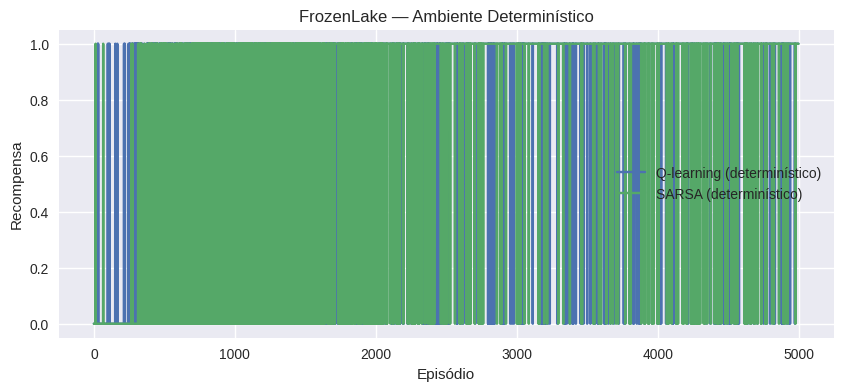

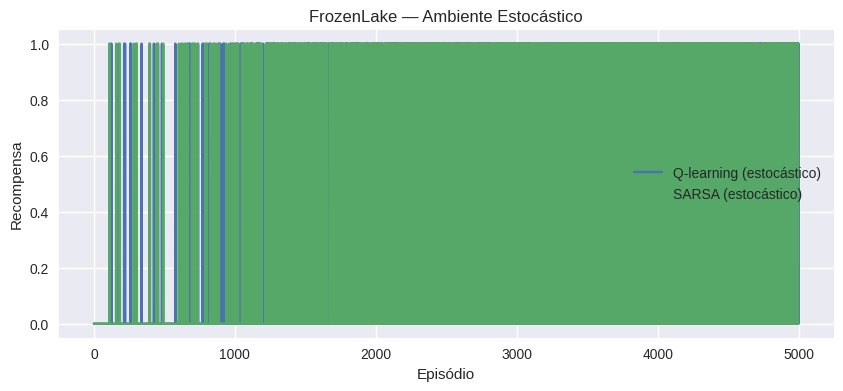

In [17]:
# Execução e comparação dos cenários

# Ambientes
env_det = make_frozenlake(is_slippery=False)
env_sto = make_frozenlake(is_slippery=True)

# Determinístico
Q_q_det, r_q_det, s_q_det = q_learning_frozenlake(env_det)
Q_s_det, r_s_det, s_s_det = sarsa_frozenlake(env_det)

# Estocástico
Q_q_sto, r_q_sto, s_q_sto = q_learning_frozenlake(env_sto)
Q_s_sto, r_s_sto, s_s_sto = sarsa_frozenlake(env_sto)

# ---- Gráficos: Recompensa ----
plt.figure()
plt.plot(r_q_det, label="Q-learning (determinístico)")
plt.plot(r_s_det, label="SARSA (determinístico)")
plt.xlabel("Episódio")
plt.ylabel("Recompensa")
plt.title("FrozenLake — Ambiente Determinístico")
plt.legend()
plt.show()

plt.figure()
plt.plot(r_q_sto, label="Q-learning (estocástico)")
plt.plot(r_s_sto, label="SARSA (estocástico)")
plt.xlabel("Episódio")
plt.ylabel("Recompensa")
plt.title("FrozenLake — Ambiente Estocástico")
plt.legend()
plt.show()

## Interpretação dos Resultados — Atividade 3

Os gráficos apresentados ilustram a evolução da **recompensa por episódio** para os algoritmos **Q-learning** e **SARSA** no ambiente FrozenLake, considerando dois cenários distintos: um ambiente determinístico (`is_slippery=False`) e um ambiente estocástico (`is_slippery=True`). Como a recompensa no FrozenLake é binária, assumindo valor 1 apenas quando o agente alcança o estado objetivo e 0 nos demais casos, os gráficos refletem diretamente a taxa de sucesso do agente ao longo do treinamento.

No **ambiente determinístico**, observa-se que ambos os algoritmos conseguem aprender uma política eficaz após um número relativamente pequeno de episódios. A partir desse ponto, a recompensa passa a assumir valor 1 com alta frequência, indicando que o agente aprendeu um caminho seguro até o objetivo. As oscilações observadas ao longo do treinamento estão associadas à política ε-greedy, que mantém um nível residual de exploração, mesmo após a convergência. Nesse cenário, as diferenças entre Q-learning e SARSA são pouco pronunciadas, uma vez que a ausência de incerteza nas transições reduz o risco associado à exploração.

No **ambiente estocástico**, o comportamento é substancialmente diferente. Embora ambos os algoritmos eventualmente aprendam políticas que alcançam o objetivo com maior frequência, o processo de aprendizado apresenta maior variabilidade, especialmente nos episódios iniciais. A presença de estocasticidade faz com que a ação executada nem sempre corresponda à ação escolhida pelo agente, aumentando a variância do retorno e dificultando a estimativa precisa dos valores de ação. Nesse contexto, observa-se que o SARSA tende a apresentar um comportamento mais estável ao longo do treinamento, enquanto o Q-learning pode exibir maior sensibilidade à exploração, uma vez que atualiza seus valores com base em ações ótimas assumidas, e não necessariamente executadas.

De forma geral, os resultados confirmam que a **estocasticidade do ambiente aumenta significativamente a dificuldade do aprendizado**, exigindo mais episódios para a convergência e tornando o processo mais instável. Além disso, evidenciam a diferença conceitual entre abordagens *off-policy* e *on-policy*, mostrando que algoritmos como o SARSA tendem a ser mais conservadores e robustos em ambientes incertos, enquanto o Q-learning pode apresentar desempenho mais agressivo, porém potencialmente menos estável.


## Atividade 4 — Análise da Política Aprendida

Esta atividade tem como objetivo analisar a **política final aprendida pelos agentes** após o processo de treinamento, verificando se o comportamento resultante é coerente com a estrutura e os objetivos de cada ambiente. Diferentemente das atividades anteriores, que focaram na dinâmica do aprendizado e na convergência dos algoritmos, o foco aqui é a **interpretação do comportamento do agente** a partir da política ótima extraída da Q-table.

A análise é conduzida nos ambientes **FrozenLake** e **Taxi**, que apresentam desafios distintos. No FrozenLake, a política aprendida deve refletir caminhos seguros até o objetivo, evitando estados terminais negativos. No ambiente Taxi, a política envolve uma sequência hierárquica de decisões, incluindo deslocamento, coleta do passageiro e entrega no destino correto, sendo penalizadas ações inválidas.

A visualização da política aprendida e da execução da política greedy permite avaliar qualitativamente o desempenho dos algoritmos e confirmar se o agente internalizou as regras e restrições impostas pelo ambiente.


In [18]:
# Política aprendida no FrozenLake (visualização por setas)

def plot_policy_frozenlake(Q, env):
    """
    Exibe a política aprendida no FrozenLake usando setas.
    """
    actions = {
        0: "←",
        1: "↓",
        2: "→",
        3: "↑"
    }

    n_states = env.observation_space.n
    size = int(np.sqrt(n_states))

    policy = np.argmax(Q, axis=1)
    grid = np.reshape(policy, (size, size))

    print("Política aprendida (FrozenLake):\n")
    for i in range(size):
        row = []
        for j in range(size):
            row.append(actions[grid[i, j]])
        print(" ".join(row))

In [19]:
plot_policy_frozenlake(Q_s_det, env_det)
plot_policy_frozenlake(Q_s_sto, env_sto)


Política aprendida (FrozenLake):

↓ ← ↓ ←
↓ ← ↓ ←
→ → ↓ ←
← → → ←
Política aprendida (FrozenLake):

← ↑ ↑ ↑
← ← → ←
↑ ↓ ← ←
← → ↓ ←


In [20]:
# Execução da política greedy no FrozenLake (GIF)
def generate_gif_frozenlake(env, Q, filename, max_steps=50):
    frames = []
    env = gym.make(
        "FrozenLake-v1",
        is_slippery=env.spec.kwargs["is_slippery"],
        render_mode="rgb_array"
    )

    state, _ = env.reset()
    done = False
    steps = 0

    while not done and steps < max_steps:
        frames.append(env.render())
        action = np.argmax(Q[state])
        state, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        steps += 1

    imageio.mimsave(filename, frames, fps=3)

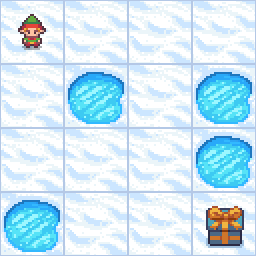

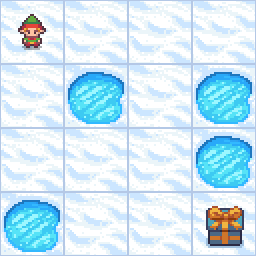

In [21]:
generate_gif_frozenlake(env_det, Q_s_det, "frozen_det_sarsa.gif")
generate_gif_frozenlake(env_sto, Q_s_sto, "frozen_sto_sarsa.gif")

display(Image(filename="frozen_det_sarsa.gif"))
display(Image(filename="frozen_sto_sarsa.gif"))


In [22]:
# Política aprendida no Taxi (execução interpretável)

def run_policy_taxi(Q, max_steps=50):
    env = gym.make("Taxi-v3", render_mode="rgb_array")
    frames = []

    state, _ = env.reset()
    done = False
    steps = 0

    while not done and steps < max_steps:
        frames.append(env.render())
        action = np.argmax(Q[state])
        state, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        steps += 1

    imageio.mimsave("taxi_policy.gif", frames, fps=3)
    display(Image(filename="taxi_policy.gif"))

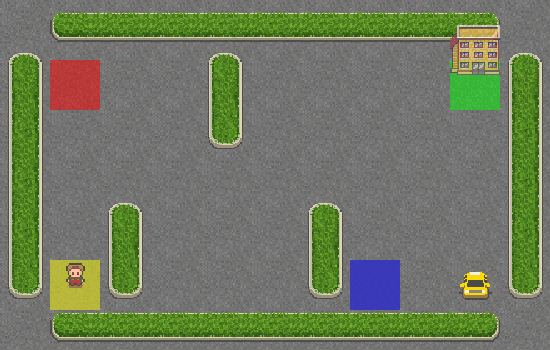

In [23]:
env_taxi = gym.make("Taxi-v3")

Q_taxi, _, _ = q_learning_frozenlake(env_taxi, n_episodes=5000)

run_policy_taxi(Q_taxi)


## Interpretação dos Resultados — Atividade 4

A análise da política aprendida permite avaliar qualitativamente o comportamento final do agente após o processo de treinamento, verificando se as decisões tomadas são consistentes com os objetivos e restrições de cada ambiente.

No **FrozenLake**, a execução da política greedy evidencia que o agente aprendeu a navegar pelo ambiente evitando os estados terminais negativos (buracos) e priorizando trajetórias que conduzem de forma segura ao estado objetivo. Mesmo em um ambiente com recompensas esparsas, a política aprendida demonstra coerência espacial, seguindo caminhos contínuos e minimizando movimentos desnecessários. Esse comportamento confirma que a Q-table capturou corretamente a estrutura do ambiente e que o agente foi capaz de internalizar a relação entre estados, ações e recompensas, resultando em uma política eficaz.

No **ambiente Taxi**, a execução da política greedy revela um comportamento mais complexo e hierárquico. Observa-se que o agente inicialmente se desloca até a posição do passageiro, executa corretamente a ação de coleta e, em seguida, planeja o trajeto até o destino final, evitando ações inválidas que acarretariam penalidades. A política aprendida reflete a compreensão das regras do ambiente, incluindo as restrições associadas às ações de pegar e deixar o passageiro, bem como a necessidade de planejamento de longo prazo para maximizar a recompensa acumulada.




## Conclusão Geral

Este trabalho apresentou uma análise empírica dos algoritmos clássicos de Aprendizado por Reforço baseados em Diferença Temporal, com foco no **Q-learning** e no **SARSA**, aplicados a ambientes com níveis crescentes de complexidade. Por meio da implementação prática e da avaliação sistemática dos resultados, foi possível compreender tanto os aspectos teóricos quanto os comportamentos observáveis desses algoritmos em diferentes cenários.

No ambiente **GridWorld**, caracterizado por transições determinísticas e baixa complexidade, ambos os algoritmos demonstraram rápida convergência para políticas eficientes. A análise das métricas de recompensa e número de passos por episódio evidenciou a capacidade dos agentes de aprender trajetórias ótimas, validando a correta implementação dos métodos e estabelecendo uma base sólida para as análises subsequentes. A inspeção da política aprendida confirmou que os agentes internalizaram adequadamente a estrutura espacial do ambiente.

A **análise da estratégia de exploração** revelou que a escolha de ε exerce papel fundamental no processo de aprendizado. Os resultados mostraram que o uso de uma política ε-greedy com **ε decrescente** favorece a convergência para políticas mais estáveis e eficientes, ao permitir uma exploração intensa nos estágios iniciais e uma exploração progressivamente menor à medida que o agente acumula conhecimento. Em contraste, o uso de ε constante manteve oscilações residuais no desempenho, mesmo após longos períodos de treinamento.

No ambiente **FrozenLake**, a introdução de **estocasticidade nas transições de estado** aumentou significativamente a dificuldade do aprendizado. Observou-se que, embora ambos os algoritmos fossem capazes de aprender políticas viáveis, o processo tornou-se mais instável e exigiu um maior número de episódios para a convergência. Nesse contexto, o SARSA apresentou um comportamento mais conservador e estável, enquanto o Q-learning mostrou maior sensibilidade à exploração, refletindo as diferenças conceituais entre abordagens *on-policy* e *off-policy*.

Por fim, a análise da política aprendida no ambiente **Taxi** evidenciou a capacidade dos algoritmos de lidar com espaços de estados mais amplos e decisões hierárquicas. A execução da política greedy demonstrou que o agente aprendeu corretamente a sequência de ações necessárias para coletar o passageiro e entregá-lo ao destino, respeitando as restrições do ambiente e evitando ações inválidas.


